In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

In [37]:
df_sales = pd.read_csv(r"C:\Users\ASUS\Desktop\Desktop\Infotact Internship\Project 1 clean\Project-1-Omnichannel-retail-analysis-clean\cleaned_data\retail_sales_cleaned.csv")
df_inv = pd.read_csv(r"C:\Users\ASUS\Desktop\Desktop\Infotact Internship\Project 1 clean\Project-1-Omnichannel-retail-analysis-clean\cleaned_data\retail_inventory_cleaned.csv")

In [38]:
df_inv.isna().sum()
df_inv.info()

<class 'pandas.DataFrame'>
RangeIndex: 284755 entries, 0 to 284754
Data columns (total 18 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   start_date                284755 non-null  str    
 1   end_date                  284755 non-null  str    
 2   stock_status              284755 non-null  str    
 3   supplier                  284755 non-null  str    
 4   product_no                284755 non-null  str    
 5   product_description       284755 non-null  str    
 6   product_division          284755 non-null  str    
 7   product_category          284755 non-null  str    
 8   product_subcategory       284755 non-null  str    
 9   product_segment           284755 non-null  str    
 10  store                     284755 non-null  str    
 11  store_type                284755 non-null  str    
 12  sales_channel             284755 non-null  str    
 13  qty_on_hand               284755 non-null  int64  
 14 

In [39]:
df_inv.head()

,start_date,end_date,stock_status,supplier,product_no,product_description,product_division,product_category,product_subcategory,product_segment,store,store_type,sales_channel,qty_on_hand,stocks_selling_amount,cost_of_stocks,stock_unit_selling_price,stock_unit_cost_price
0,2025-08-07,2025-10-18,Full Price,Vendor 0255,PROD-159369,PROD-103395 SEG-500461 Scholar Footwear Canvas...,Scholar Footwear,Scholar Footwear Canvas Styles,Scholar Footwear Canvas Styles Drifter,SEG-500461 Scholar Footwear Canvas Styles Drifter,STR-1010,Retail Storefront,Channel Alpha,1,55.0,24.75,55.0,24.75
1,2026-02-15,2026-02-15,Full Price,Vendor 0010,PROD-180713,PROD-190644 SEG-520887 Femme Footwear Court Ca...,Femme Footwear,Femme Footwear Court Casual,Femme Footwear Court Casual Trident,SEG-520887 Femme Footwear Court Casual Trident,STR-1082,Retail Storefront,Channel Alpha,1,130.0,59.73,130.0,59.73
2,2026-01-08,2026-02-15,Full Price,Vendor 0166,PROD-169474,PROD-153439 SEG-512518 Femme Footwear Court Ca...,Femme Footwear,Femme Footwear Court Casual,Femme Footwear Court Casual Zephyr,SEG-512518 Femme Footwear Court Casual Zephyr,STR-1105,Retail Storefront,Channel Alpha,1,120.0,60.44,120.0,60.44
3,2025-12-23,2026-02-15,Full Price,Vendor 0106,PROD-170976,PROD-122029 SEG-504463 Junior Apparel Cozy Pul...,Junior Apparel,Junior Apparel Cozy Pullovers,Junior Apparel Cozy Pullovers Varied,SEG-504463 Junior Apparel Cozy Pullovers Varied,STR-1157,Retail Storefront,Channel Alpha,3,150.0,52.50,50.0,17.50
4,2026-02-10,9999-12-31,Full Price,Vendor 0134,PROD-183525,PROD-111954 SEG-502325 Scholar Footwear Modern...,Scholar Footwear,Scholar Footwear Modern Legend,Scholar Footwear Modern Legend Summit,SEG-502325 Scholar Footwear Modern Legend Summit,STR-1253,Retail Storefront,Channel Alpha,4,360.0,182.16,90.0,45.54


In [40]:
df_sales.head()

,transaction_date,sales_type,is_return,supplier,product_no,product_description,product_division,product_category,product_subcategory,product_segment,store,sales_channel,qty_sold,sales_amount,cogs,number_of_transactions
0,2025-09-01,Full Price,0,Vendor 0169,PROD-139867,PROD-100449 SEG-500065 Scholar Footwear Trailb...,Scholar Footwear,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Equilibrium,SEG-500065 Scholar Footwear Trailblazer Equili...,STR-1006,Channel Alpha,1.0,115.00,52.31,1
1,2025-09-07,Full Price,0,Vendor 0166,PROD-100449,PROD-100825 SEG-500112 Heritage Footwear Fligh...,Femme Footwear,Femme Footwear Flight Classic,Femme Footwear Flight Classic Varied,SEG-500112 Heritage Footwear Flight Classic Ze...,STR-1198,Channel Alpha,1.0,115.00,58.47,1
2,2025-08-06,Promo,0,Vendor 0169,PROD-153623,PROD-148813 SEG-511388 Scholar Footwear Trailb...,Scholar Footwear,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Equilibrium,SEG-511388 Scholar Footwear Trailblazer Equili...,STR-1157,Channel Alpha,1.0,79.99,43.76,1
3,2025-08-31,Full Price,0,Vendor 0246,PROD-140876,PROD-100419 SEG-500063 Scholar Footwear Boot C...,Scholar Footwear,Scholar Footwear Boot Collection,Scholar Footwear Boot Collection Woodland,SEG-500063 Scholar Footwear Boot Collection Wo...,STR-1234,Channel Alpha,1.0,110.00,50.60,1
4,2026-03-22,Full Price,0,Vendor 0169,PROD-166113,PROD-149345 SEG-511444 Femme Footwear Trailbla...,Femme Footwear,Femme Footwear Trailblazer,Femme Footwear Trailblazer Equilibrium,SEG-511444 Femme Footwear Trailblazer Equilibrium,STR-1157,Channel Alpha,1.0,160.00,77.95,1


In [41]:
df_sales['transaction_date'] = pd.to_datetime( df_sales['transaction_date'], format='mixed', dayfirst=True)
df_inv['start_date'] = pd.to_datetime(df_inv['start_date'], )
df_inv['end_date'] = pd.to_datetime(df_inv['end_date'], errors='coerce')

### Important Time Columns

In [42]:
df_sales['year'] = df_sales['transaction_date'].dt.year
df_sales['month'] = df_sales['transaction_date'].dt.month
df_sales['month_name'] = df_sales['transaction_date'].dt.month_name()

df_sales['day'] = df_sales['transaction_date'].dt.day

df_sales['weekday'] = df_sales['transaction_date'].dt.day_name()

df_sales['weekend_flag'] = np.where(
    df_sales['weekday'].isin(['Saturday', 'Sunday']),
    'Weekend',
    'Weekday'
)

### Outlier Analysis - Descriptive Statistics

This section provides descriptive statistics for the numerical columns in both `df_sales` and `df_inv`. These statistics (mean, std, min, max, quartiles) offer a preliminary understanding of the data distribution and help identify potential outliers.

In [43]:
sales_numeric_cols = ['qty_sold', 'sales_amount', 'cogs', 'number_of_transactions']
inv_numeric_cols = ['qty_on_hand', 'stocks_selling_amount', 'cost_of_stocks', 'stock_unit_selling_price', 'stock_unit_cost_price']

print("\nDescriptive statistics for df_sales numerical columns:")
display(df_sales[sales_numeric_cols].describe())

print("\nDescriptive statistics for df_inv numerical columns:")
display(df_inv[inv_numeric_cols].describe())


Descriptive statistics for df_sales numerical columns:


,qty_sold,sales_amount,cogs,number_of_transactions
count,125751.000000,125751.000000,125751.000000,125751.000000
mean,0.930370,83.356079,46.502621,1.042695
std,0.586897,83.658776,43.597511,0.305832
min,-3.000000,-380.000000,-192.280000,1.000000
25%,1.000000,50.000000,37.710000,1.000000
50%,1.000000,90.000000,50.050000,1.000000
75%,1.000000,115.000000,60.720000,1.000000
max,14.000000,2660.000000,1345.960000,14.000000



Descriptive statistics for df_inv numerical columns:


,qty_on_hand,stocks_selling_amount,cost_of_stocks,stock_unit_selling_price,stock_unit_cost_price
count,284755.000000,284755.000000,284755.000000,284755.000000,284755.000000
mean,2.294629,224.392566,111.046256,95.313171,47.419488
std,2.007395,214.479811,105.785092,46.655771,23.776569
min,-9.000000,-828.000000,-418.950000,0.000000,-16.940000
25%,1.000000,95.000000,46.430000,75.000000,37.950000
50%,2.000000,160.000000,80.960000,100.000000,50.050000
75%,3.000000,300.000000,149.170000,120.000000,60.720000
max,56.000000,5600.000000,2641.450000,250.000000,336.380000


### Outlier Analysis - Visualizations (Box Plots)

Box plots are used to visually identify outliers in the numerical columns of both `df_sales` and `df_inv`. Outliers are typically represented as points falling outside the 'whiskers' of the box plot, which extend to 1.5 times the Interquartile Range (IQR) from the first and third quartiles.


Box plots for df_sales numerical columns:


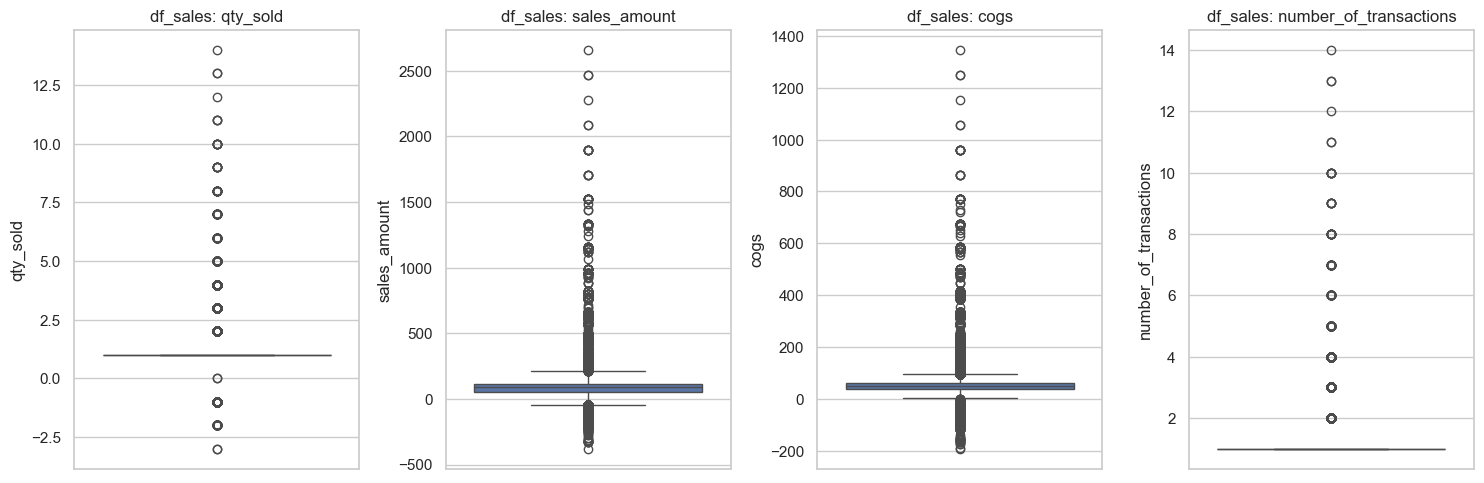


Box plots for df_inv numerical columns:


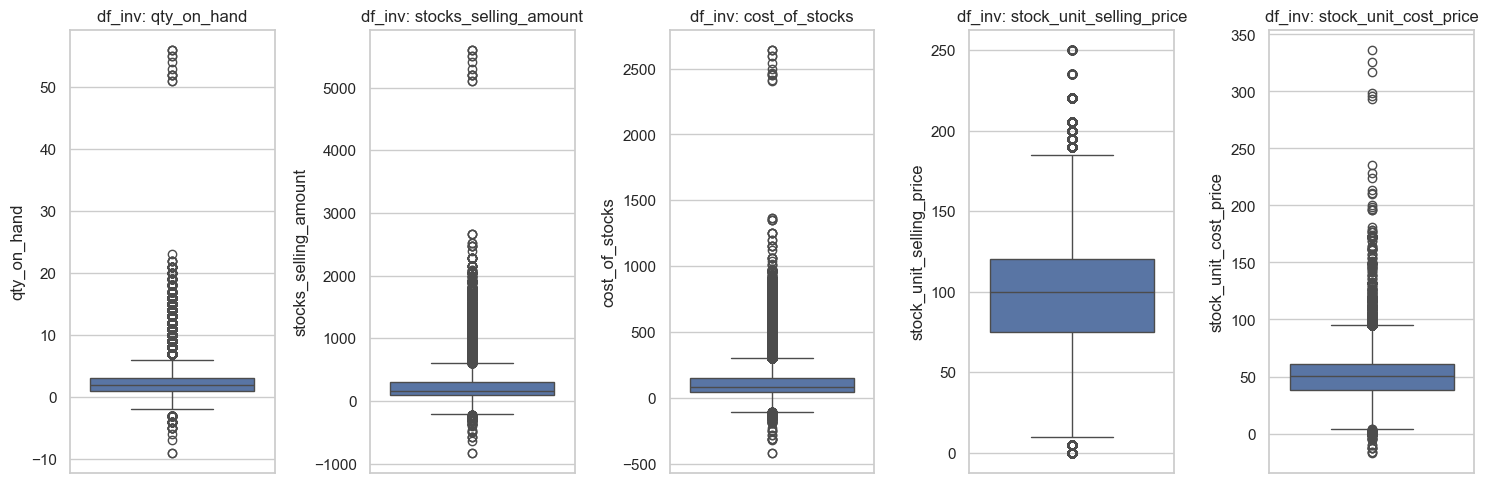

------------------------------


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

sales_numeric_cols = ['qty_sold', 'sales_amount', 'cogs', 'number_of_transactions']
inv_numeric_cols = ['qty_on_hand', 'stocks_selling_amount', 'cost_of_stocks', 'stock_unit_selling_price', 'stock_unit_cost_price']

print("\nBox plots for df_sales numerical columns:")
plt.figure(figsize=(15, 5))
for i, col in enumerate(sales_numeric_cols):
    plt.subplot(1, len(sales_numeric_cols), i + 1)
    sns.boxplot(y=df_sales[col])
    plt.title(f'df_sales: {col}')
plt.tight_layout()
plt.show()

print("\nBox plots for df_inv numerical columns:")
plt.figure(figsize=(15, 5))
for i, col in enumerate(inv_numeric_cols):
    if col in df_inv.columns: # Ensure column exists before plotting
        plt.subplot(1, len(inv_numeric_cols), i + 1)
        sns.boxplot(y=df_inv[col])
        plt.title(f'df_inv: {col}')
plt.tight_layout()
plt.show()
print("-" * 30)

### Outlier Removal Function (IQR Method)

This section defines a reusable function `remove_outliers_iqr` that identifies and removes outliers from a specified column in a DataFrame using the Interquartile Range (IQR) method. This method helps to filter out extreme values that fall significantly outside the typical range of the data.

In [45]:
def remove_outliers_iqr(df, column):
    """
    Removes outliers from a specified column in a DataFrame using the IQR method.
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_filtered

print("The `remove_outliers_iqr` function has been defined.")

The `remove_outliers_iqr` function has been defined.


### Outlier Removal - `df_sales`

This section applies the `remove_outliers_iqr` function to the numerical columns of `df_sales` to filter out outlier data points. This process helps to improve the quality and reliability of the sales data for subsequent analysis.

In [46]:
print("\n--- Removing Outliers from df_sales ---")
print(f"Initial shape of df_sales before outlier removal: {df_sales.shape}")

df_sales_cleaned = df_sales.copy()
initial_sales_rows_for_outliers = df_sales_cleaned.shape[0]

for col in sales_numeric_cols:
    if col in df_sales_cleaned.columns:
        # Ensure column is numeric and handle NaNs before outlier detection
        df_sales_cleaned[col] = pd.to_numeric(df_sales_cleaned[col], errors='coerce')
        df_sales_cleaned.dropna(subset=[col], inplace=True)
        df_sales_cleaned = remove_outliers_iqr(df_sales_cleaned, col)
        print(f"Outliers processed for df_sales['{col}']. Current shape: {df_sales_cleaned.shape}")
    else:
        print(f"Warning: Column '{col}' not found in df_sales. Skipping outlier removal.")

rows_removed_sales_outliers = initial_sales_rows_for_outliers - df_sales_cleaned.shape[0]
print(f"Total rows removed from df_sales due to outliers: {rows_removed_sales_outliers}")
print(f"Final shape of df_sales after outlier removal: {df_sales_cleaned.shape}")

df_sales = df_sales_cleaned.copy() # Update the main df_sales DataFrame

display(df_sales.head())


--- Removing Outliers from df_sales ---
Initial shape of df_sales before outlier removal: (125751, 22)
Outliers processed for df_sales['qty_sold']. Current shape: (113712, 22)
Outliers processed for df_sales['sales_amount']. Current shape: (113014, 22)
Outliers processed for df_sales['cogs']. Current shape: (104251, 22)
Outliers processed for df_sales['number_of_transactions']. Current shape: (104251, 22)
Total rows removed from df_sales due to outliers: 21500
Final shape of df_sales after outlier removal: (104251, 22)


,transaction_date,sales_type,is_return,supplier,product_no,product_description,product_division,product_category,product_subcategory,product_segment,...,qty_sold,sales_amount,cogs,number_of_transactions,year,month,month_name,day,weekday,weekend_flag
0,2025-01-09,Full Price,0,Vendor 0169,PROD-139867,PROD-100449 SEG-500065 Scholar Footwear Trailb...,Scholar Footwear,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Equilibrium,SEG-500065 Scholar Footwear Trailblazer Equili...,...,1.0,115.00,52.31,1,2025,1,January,9,Thursday,Weekday
1,2025-07-09,Full Price,0,Vendor 0166,PROD-100449,PROD-100825 SEG-500112 Heritage Footwear Fligh...,Femme Footwear,Femme Footwear Flight Classic,Femme Footwear Flight Classic Varied,SEG-500112 Heritage Footwear Flight Classic Ze...,...,1.0,115.00,58.47,1,2025,7,July,9,Wednesday,Weekday
2,2025-06-08,Promo,0,Vendor 0169,PROD-153623,PROD-148813 SEG-511388 Scholar Footwear Trailb...,Scholar Footwear,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Equilibrium,SEG-511388 Scholar Footwear Trailblazer Equili...,...,1.0,79.99,43.76,1,2025,6,June,8,Sunday,Weekend
3,2025-08-31,Full Price,0,Vendor 0246,PROD-140876,PROD-100419 SEG-500063 Scholar Footwear Boot C...,Scholar Footwear,Scholar Footwear Boot Collection,Scholar Footwear Boot Collection Woodland,SEG-500063 Scholar Footwear Boot Collection Wo...,...,1.0,110.00,50.60,1,2025,8,August,31,Sunday,Weekend
4,2026-03-22,Full Price,0,Vendor 0169,PROD-166113,PROD-149345 SEG-511444 Femme Footwear Trailbla...,Femme Footwear,Femme Footwear Trailblazer,Femme Footwear Trailblazer Equilibrium,SEG-511444 Femme Footwear Trailblazer Equilibrium,...,1.0,160.00,77.95,1,2026,3,March,22,Sunday,Weekend


### Outlier Removal - `df_inv`

This section applies the `remove_outliers_iqr` function to the numerical columns of `df_inv` to filter out outlier data points. This process helps to improve the quality and reliability of the inventory data for subsequent analysis.

In [68]:
print("\n--- Removing Outliers from df_inv ---")
print(f"Initial shape of df_inv before outlier removal: {df_inv.shape}")

df_inv_cleaned = df_inv.copy()
initial_inv_rows_for_outliers = df_inv_cleaned.shape[0]

for col in inv_numeric_cols:
    if col in df_inv_cleaned.columns:
        # Ensure column is numeric and handle NaNs before outlier detection
        df_inv_cleaned[col] = pd.to_numeric(df_inv_cleaned[col], errors='coerce')
        df_inv_cleaned.dropna(subset=[col], inplace=True)
        df_inv_cleaned = remove_outliers_iqr(df_inv_cleaned, col)
        print(f"Outliers processed for df_inv['{col}']. Current shape: {df_inv_cleaned.shape}")
    else:
        print(f"Warning: Column '{col}' not found in df_inv. Skipping outlier removal.")

rows_removed_inv_outliers = initial_inv_rows_for_outliers - df_inv_cleaned.shape[0]
print(f"Total rows removed from df_inv due to outliers: {rows_removed_inv_outliers}")
print(f"Final shape of df_inv after outlier removal: {df_inv_cleaned.shape}")

df_inv = df_inv_cleaned.copy() # Update the main df_inv DataFrame

display(df_inv.head())


--- Removing Outliers from df_inv ---
Initial shape of df_inv before outlier removal: (252079, 21)
Outliers processed for df_inv['qty_on_hand']. Current shape: (226754, 21)
Outliers processed for df_inv['stocks_selling_amount']. Current shape: (224476, 21)
Outliers processed for df_inv['cost_of_stocks']. Current shape: (224369, 21)
Outliers processed for df_inv['stock_unit_selling_price']. Current shape: (224369, 21)
Outliers processed for df_inv['stock_unit_cost_price']. Current shape: (224209, 21)
Total rows removed from df_inv due to outliers: 27870
Final shape of df_inv after outlier removal: (224209, 21)


,start_date,end_date,stock_status,supplier,product_no,product_description,product_division,product_category,product_subcategory,product_segment,...,store_type,sales_channel,qty_on_hand,stocks_selling_amount,cost_of_stocks,stock_unit_selling_price,stock_unit_cost_price,start_date_month,end_date_month,days_in_inventory
0,2025-08-07,2025-10-18,Full Price,Vendor 0255,PROD-159369,PROD-103395 SEG-500461 Scholar Footwear Canvas...,Scholar Footwear,Scholar Footwear Canvas Styles,Scholar Footwear Canvas Styles Drifter,SEG-500461 Scholar Footwear Canvas Styles Drifter,...,Retail Storefront,Channel Alpha,1,55.0,24.75,55.0,24.75,8,10,300
1,2026-02-15,2026-02-15,Full Price,Vendor 0010,PROD-180713,PROD-190644 SEG-520887 Femme Footwear Court Ca...,Femme Footwear,Femme Footwear Court Casual,Femme Footwear Court Casual Trident,SEG-520887 Femme Footwear Court Casual Trident,...,Retail Storefront,Channel Alpha,1,130.0,59.73,130.0,59.73,2,2,108
2,2026-01-08,2026-02-15,Full Price,Vendor 0166,PROD-169474,PROD-153439 SEG-512518 Femme Footwear Court Ca...,Femme Footwear,Femme Footwear Court Casual,Femme Footwear Court Casual Zephyr,SEG-512518 Femme Footwear Court Casual Zephyr,...,Retail Storefront,Channel Alpha,1,120.0,60.44,120.0,60.44,1,2,146
3,2025-12-23,2026-02-15,Full Price,Vendor 0106,PROD-170976,PROD-122029 SEG-504463 Junior Apparel Cozy Pul...,Junior Apparel,Junior Apparel Cozy Pullovers,Junior Apparel Cozy Pullovers Varied,SEG-504463 Junior Apparel Cozy Pullovers Varied,...,Retail Storefront,Channel Alpha,3,150.0,52.50,50.0,17.50,12,2,162
5,2025-06-09,2026-01-07,Full Price,Vendor 0166,PROD-124597,PROD-100989 SEG-500125 Toddler Footwear Flight...,Scholar Footwear,Scholar Footwear Flight Classic,Scholar Footwear Flight Classic Zephyr,SEG-500125 Toddler Footwear Flight Classic Zephyr,...,Retail Storefront,Channel Alpha,0,0.0,-6.80,0.0,0.00,6,1,359


### Final DataFrames After Outlier Removal

This section confirms the final shapes of `df_sales` and `df_inv` after all cleaning and outlier removal processes have been applied.

In [69]:
print("\nOutlier removal complete for both DataFrames.")
print(f"Final shape of df_sales: {df_sales.shape}")
print(f"Final shape of df_inv: {df_inv.shape}")


Outlier removal complete for both DataFrames.
Final shape of df_sales: (104251, 23)
Final shape of df_inv: (224209, 21)


### Creating Business KPIs

#### Store managers care about:

- Revenue
- Profit
- Fast moving products
- Store performance
- Weekend sales
- Inventory availability

In [70]:
#Create Profit Column
df_sales['profit'] = df_sales['sales_amount'] - df_sales['cogs']

#### Daily Revenue Trend

In [71]:
daily_sales = df_sales.groupby('transaction_date').agg({
    'sales_amount':'sum',
    'profit':'sum',
    'qty_sold':'sum'
}).reset_index()
print(daily_sales)

    transaction_date  sales_amount    profit  qty_sold
0         2025-01-06      20836.80   9998.86     209.0
1         2025-01-07      17833.29   8321.60     188.0
2         2025-01-08      50953.40  23070.34     534.0
3         2025-01-09      46427.69  21983.06     486.0
4         2025-01-10      17175.21   6938.17     188.0
..               ...           ...       ...       ...
321       2026-11-04      34590.16  15117.80     396.0
322       2026-12-01      13295.27   5170.09     162.0
323       2026-12-02      31847.37  14298.95     330.0
324       2026-12-03      29826.57  11165.97     374.0
325       2026-12-04      19970.05   8829.61     219.0

[326 rows x 4 columns]


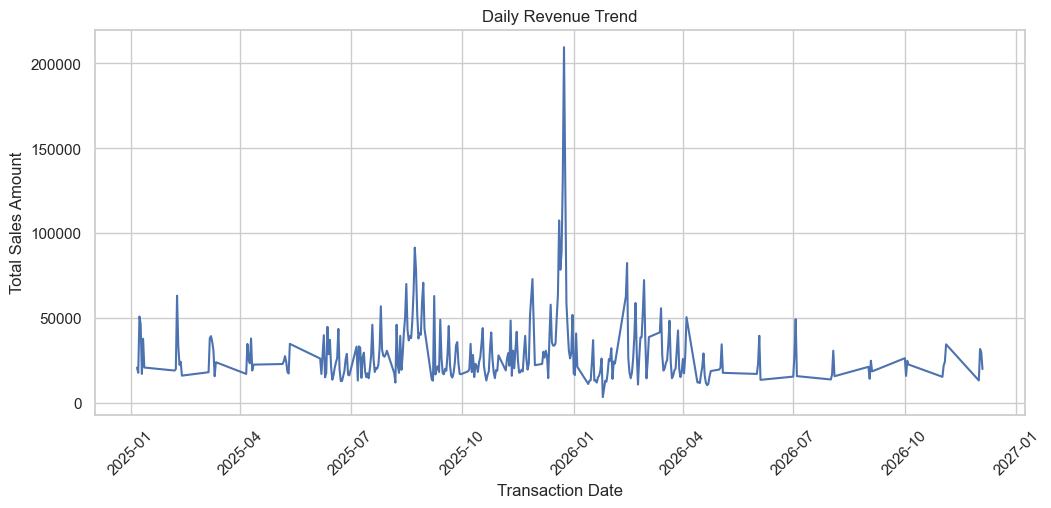

In [72]:
plt.figure(figsize=(12, 5))
plt.plot( daily_sales['transaction_date'], daily_sales['sales_amount'])
plt.title("Daily Revenue Trend")
plt.xlabel("Transaction Date")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

#### Weekday vs Weekend Performance

In [52]:
weekend_analysis = df_sales.groupby('weekend_flag').agg({
    'sales_amount':'sum',
    'profit':'sum',
    'qty_sold':'sum'
}).reset_index()
print(weekend_analysis)

#Revenue Comparison
total = 6661650.38 + 3820459.87

weekday_percent = (6661650.38 / total) * 100
weekend_percent = (3820459.87 / total) * 100

print("Weekday % :", round(weekday_percent,2))
print("Weekend % :", round(weekend_percent,2))


  weekend_flag  sales_amount       profit  qty_sold
0      Weekday    6260195.13  2747267.625   68864.0
1      Weekend    3252172.73  1435543.190   35387.0
Weekday % : 63.55
Weekend % : 36.45


- The analysis shows that weekday sales contribute significantly more revenue than weekend sales. Approximately 63% of total revenue is generated during weekdays, indicating stronger customer purchasing activity on working days. Weekend sales still contribute a substantial portion of revenue but remain lower in comparison. This insight can help store managers optimize staffing, inventory allocation, and promotional campaigns based on customer traffic patterns.
---
#### Store manager can:

- Keep higher staff availability on weekdays
- Maintain more inventory during weekdays
- Run weekend promotions to increase traffic
- Identify if certain categories perform better on weekends

#### This can be misleading because:

- Weekdays = 5 days
- Weekend = 2 days

So naturally weekdays may have higher totals.

 so we calculate,  
#### Average sales per weekday vs per weekend day

In [53]:
daily_type_sales = df_sales.groupby(
    ['transaction_date', 'weekend_flag']
)['sales_amount'].sum().reset_index()

print("daily_type_sales : ")
print(daily_type_sales)
print()

avg_sales = daily_type_sales.groupby(
    'weekend_flag'
)['sales_amount'].mean().reset_index()

print('Average sales per weekday vs per weekend day ')
print(avg_sales)

daily_type_sales : 
    transaction_date weekend_flag  sales_amount
0         2025-01-06      Weekday      20836.80
1         2025-01-07      Weekday      17833.29
2         2025-01-08      Weekday      50953.40
3         2025-01-09      Weekday      46427.69
4         2025-01-10      Weekday      17175.21
..               ...          ...           ...
321       2026-11-04      Weekday      34590.16
322       2026-12-01      Weekday      13295.27
323       2026-12-02      Weekday      31847.37
324       2026-12-03      Weekday      29826.57
325       2026-12-04      Weekday      19970.05

[326 rows x 3 columns]

Average sales per weekday vs per weekend day 
  weekend_flag  sales_amount
0      Weekday  26983.599698
1      Weekend  34597.582234


#### so in summery : 
- Total weekday revenue > total weekend revenue
- Average revenue per weekend day > average revenue per weekday

#### This means:

- Customers spend more per day on weekends.

#### Product Category Trends

In [54]:
category_sales = df_sales.groupby('product_category').agg({
    'sales_amount':'sum',
    'profit':'sum',
    'qty_sold':'sum'
}).sort_values(by='sales_amount', ascending=False)

print(category_sales)

                                  sales_amount      profit  qty_sold
product_category                                                    
Scholar Footwear Trailblazer        1932663.25  938032.440   20835.0
Scholar Footwear Retro Legend       1297943.10  602444.520    8856.0
Femme Footwear Trailblazer          1268063.41  453202.440   12721.0
Scholar Footwear Modern Legend      1096878.78  422262.745   10992.0
Scholar Footwear Flight Classic      718132.67  331108.970    8359.0
Scholar Footwear Court Casual        713457.22  288707.990    9637.0
Femme Footwear Court Casual          676995.32  254221.620    7540.0
Scholar Footwear Boot Collection     616423.12  334380.710    5673.0
Femme Footwear Boot Collection       312761.03  158671.320    2392.0
Femme Footwear Flight Classic        309099.35  143288.270    2779.0
Junior Apparel Cozy Trousers          89731.83   37254.270    2957.0
Junior Apparel Cozy Pullovers         89274.35   36412.690    2731.0
Scholar Footwear Trainer          

#### Fast-Moving Inventory
Fast-moving inventory means:
- Products that sell quickly and frequently.

Store managers care because:

- these products need frequent restocking
- stockouts hurt revenue
- these products indicate customer demand

##### BEST METRIC : "qty_sold" , "number_of_transactions"

In [55]:
fast_moving = df_sales.groupby('product_category').agg({
    'qty_sold':'sum',
    'sales_amount':'sum',
    'number_of_transactions':'sum'
})

In [56]:
fast_moving = fast_moving.sort_values(
    by='qty_sold',
    ascending=False
)
fast_moving

,qty_sold,sales_amount,number_of_transactions
product_category,,,
Scholar Footwear Trailblazer,20835.0,1932663.25,20835
Femme Footwear Trailblazer,12721.0,1268063.41,12721
Scholar Footwear Modern Legend,10992.0,1096878.78,10992
Scholar Footwear Court Casual,9637.0,713457.22,9637
Scholar Footwear Retro Legend,8856.0,1297943.10,8856
Scholar Footwear Flight Classic,8359.0,718132.67,8359
Femme Footwear Court Casual,7540.0,676995.32,7540
Scholar Footwear Boot Collection,5673.0,616423.12,5673
Junior Apparel Cozy Trousers,2957.0,89731.83,2957


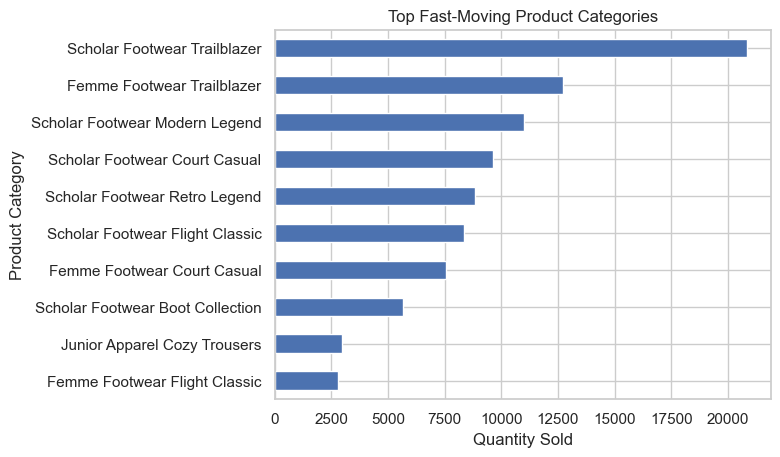

In [57]:
top_fast_moving = fast_moving.head(10)

top_fast_moving['qty_sold'].plot(kind='barh')
plt.xlabel("Quantity Sold")
plt.ylabel("Product Category")
plt.title("Top Fast-Moving Product Categories")
plt.gca().invert_yaxis()
plt.show()

In [58]:
df_inv.columns


Index(['start_date', 'end_date', 'stock_status', 'supplier', 'product_no',
       'product_description', 'product_division', 'product_category',
       'product_subcategory', 'product_segment', 'store', 'store_type',
       'sales_channel', 'qty_on_hand', 'stocks_selling_amount',
       'cost_of_stocks', 'stock_unit_selling_price', 'stock_unit_cost_price'],
      dtype='str')

In [59]:
#sales amount group by sales type 
grp = df_sales.groupby('sales_type')['sales_amount'].sum()
grp

print(grp['Clearance'] + grp['Full Price'])

8004762.59


In [60]:
df_inv['start_date_month'] = df_inv['start_date'].dt.month
df_inv['end_date_month'] = df_inv['end_date'].dt.month

df_inv_sorted = df_inv.sort_values(by="start_date")
df_inv_sorted[df_inv_sorted['product_category'] == 'Femme Footwear Trailblazer']


,start_date,end_date,stock_status,supplier,product_no,product_description,product_division,product_category,product_subcategory,product_segment,store,store_type,sales_channel,qty_on_hand,stocks_selling_amount,cost_of_stocks,stock_unit_selling_price,stock_unit_cost_price,start_date_month,end_date_month
284754,2025-06-01,2025-06-27,Full Price,Vendor 0166,PROD-124435,PROD-154330 SEG-512711 Femme Footwear Trailbla...,Femme Footwear,Femme Footwear Trailblazer,Femme Footwear Trailblazer Zephyr,SEG-512711 Femme Footwear Trailblazer Zephyr,STR-1305,Retail Storefront,Channel Alpha,2,340.00,160.16,170.00,80.080,6,6
178429,2025-06-01,2025-06-17,Full Price,Vendor 0166,PROD-158668,PROD-174345 SEG-517028 Femme Footwear Trailbla...,Femme Footwear,Femme Footwear Trailblazer,Femme Footwear Trailblazer Zephyr,SEG-517028 Femme Footwear Trailblazer Zephyr,STR-1074,Retail Storefront,Channel Alpha,2,340.00,160.16,170.00,80.080,6,6
178296,2025-06-01,2025-06-11,Full Price,Vendor 0166,PROD-158664,PROD-174349 SEG-517028 Femme Footwear Trailbla...,Femme Footwear,Femme Footwear Trailblazer,Femme Footwear Trailblazer Zephyr,SEG-517028 Femme Footwear Trailblazer Zephyr,STR-1010,Retail Storefront,Channel Alpha,1,170.00,80.08,170.00,80.080,6,6
178295,2025-06-01,2025-06-11,Full Price,Vendor 0166,PROD-158663,PROD-174350 SEG-517028 Femme Footwear Trailbla...,Femme Footwear,Femme Footwear Trailblazer,Femme Footwear Trailblazer Zephyr,SEG-517028 Femme Footwear Trailblazer Zephyr,STR-1075,Retail Storefront,Channel Alpha,1,170.00,80.08,170.00,80.080,6,6
178294,2025-06-01,2025-06-11,Full Price,Vendor 0166,PROD-158662,PROD-174351 SEG-517028 Femme Footwear Trailbla...,Femme Footwear,Femme Footwear Trailblazer,Femme Footwear Trailblazer Zephyr,SEG-517028 Femme Footwear Trailblazer Zephyr,STR-1010,Retail Storefront,Channel Alpha,1,170.00,80.08,170.00,80.080,6,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248217,2026-04-24,9999-12-31,Full Price,Vendor 0166,PROD-124437,PROD-154332 SEG-512711 Femme Footwear Trailbla...,Femme Footwear,Femme Footwear Trailblazer,Femme Footwear Trailblazer Zephyr,SEG-512711 Femme Footwear Trailblazer Zephyr,STR-1148,Retail Storefront,Channel Alpha,1,170.00,86.02,170.00,86.020,4,12
67813,2026-04-24,9999-12-31,Full Price,Vendor 0166,PROD-124431,PROD-154326 SEG-512711 Femme Footwear Trailbla...,Femme Footwear,Femme Footwear Trailblazer,Femme Footwear Trailblazer Zephyr,SEG-512711 Femme Footwear Trailblazer Zephyr,STR-1253,Retail Storefront,Channel Alpha,1,170.00,86.02,170.00,86.020,4,12
67812,2026-04-24,9999-12-31,Full Price,Vendor 0166,PROD-124432,PROD-154327 SEG-512711 Femme Footwear Trailbla...,Femme Footwear,Femme Footwear Trailblazer,Femme Footwear Trailblazer Zephyr,SEG-512711 Femme Footwear Trailblazer Zephyr,STR-1082,Retail Storefront,Channel Alpha,1,170.00,85.67,170.00,85.670,4,12
248216,2026-04-24,9999-12-31,Full Price,Vendor 0166,PROD-124436,PROD-154331 SEG-512711 Femme Footwear Trailbla...,Femme Footwear,Femme Footwear Trailblazer,Femme Footwear Trailblazer Zephyr,SEG-512711 Femme Footwear Trailblazer Zephyr,STR-1203,Retail Storefront,Channel Alpha,0,0.00,0.79,0.00,0.000,4,12


In [61]:
current = df_inv[df_inv['end_date'] == '31-12-9999']
print(current)
current['qty_on_hand'].sum()

       start_date   end_date     stock_status     supplier   product_no  \
4      2026-02-10 9999-12-31       Full Price  Vendor 0134  PROD-183525   
30     2025-10-07 9999-12-31       Full Price  Vendor 0262  PROD-176445   
35     2025-11-17 9999-12-31       Full Price  Vendor 0169  PROD-166155   
36     2025-11-17 9999-12-31       Full Price  Vendor 0169  PROD-166156   
37     2025-11-17 9999-12-31       Full Price  Vendor 0169  PROD-166157   
...           ...        ...              ...          ...          ...   
284731 2026-04-20 9999-12-31  Markdown Tier 1  Vendor 0037  PROD-165076   
284732 2026-04-20 9999-12-31       Full Price  Vendor 0010  PROD-165569   
284733 2026-04-20 9999-12-31       Full Price  Vendor 0010  PROD-165579   
284747 2026-04-15 9999-12-31       Full Price  Vendor 0169  PROD-168845   
284748 2026-04-15 9999-12-31       Full Price  Vendor 0258  PROD-184466   

                                      product_description  product_division  \
4       PROD-111954 

np.int64(31538)

## Dead Stock Analysis

Dead stock refers to inventory that has not been sold or used for a long period, indicating low or no demand. Identifying dead stock is crucial for inventory management as it ties up capital, occupies warehouse space, and may incur holding costs. 

To analyze dead stock, we will follow these steps:
1.  **Determine Last Sale Date:** For each unique product, find the most recent transaction date from the sales data.
2.  **Establish Analysis Date:** Use the latest transaction date in the entire sales dataset as our reference point.
3.  **Merge Data:** Combine the inventory data with the last sale date information.
4.  **Calculate Days Since Last Sale:** For products currently in stock, calculate how many days have passed since their last sale.
5.  **Define Dead Stock Threshold:** Set a threshold (e.g., 90 days) to classify products as dead stock if they have been in stock with no sales activity for longer than this period.
6.  **Quantify and Summarize:** Identify and summarize the quantity and value of dead stock.

In [75]:
# Step 1: Determine the last sale date for each product
# We'll consider any transaction as a 'sale' for this purpose, excluding returns if 'is_return' is available.
# Assuming 'is_return' is 0 for sales and 1 for returns based on previous context.

# Filter out returns to get actual sales dates
df_sales_actual = df_sales[df_sales['is_return'] == 0].copy()

# Get the maximum transaction date for each product
last_sale_date_per_product = df_sales_actual.groupby('product_no')['transaction_date'].max().reset_index()
last_sale_date_per_product.rename(columns={'transaction_date': 'last_sale_date'}, inplace=True)

display(last_sale_date_per_product.head())

,product_no,last_sale_date
0,PROD-100043,2026-03-01
1,PROD-100044,2026-06-02
2,PROD-100045,2026-03-29
3,PROD-100051,2026-01-31
4,PROD-100052,2026-03-18


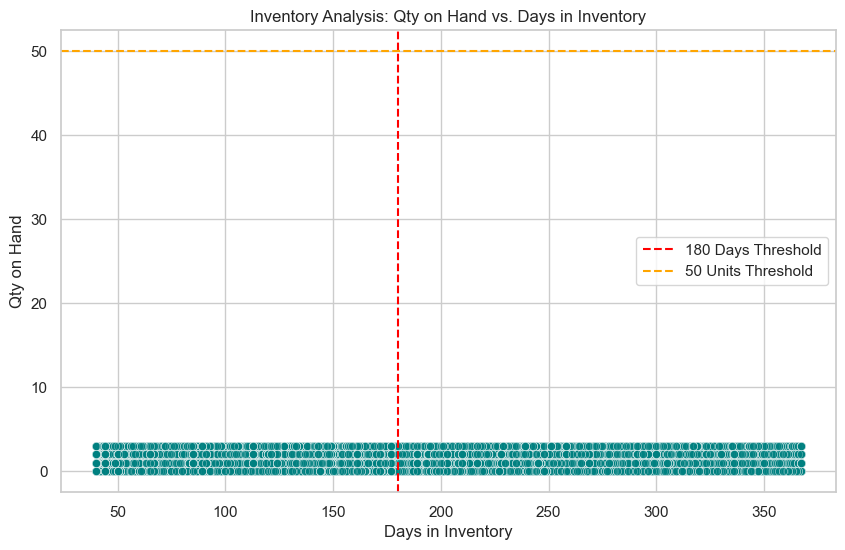

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_inv, x='days_in_inventory', y='qty_on_hand', alpha=0.6, color='teal')
plt.axvline(x=180, color='red', linestyle='--', label='180 Days Threshold')
plt.axhline(y=50, color='orange', linestyle='--', label='50 Units Threshold')
plt.title('Inventory Analysis: Qty on Hand vs. Days in Inventory')
plt.xlabel('Days in Inventory')
plt.ylabel('Qty on Hand')
plt.legend()
plt.show()

In [77]:
# Step 2: Establish a 'current' analysis date
# This will be the latest transaction date observed in the sales data.
current_analysis_date = df_sales['transaction_date'].max()
print(f"Current Analysis Date (latest transaction date): {current_analysis_date}")

Current Analysis Date (latest transaction date): 2026-12-04 00:00:00


In [78]:
# Step 3: Merge inventory data with last sale date information
# We only care about inventory items that are currently 'on hand' (qty_on_hand > 0).
# We also want to consider the latest inventory record for each product if there are multiple.

# Filter df_inv for items currently in stock
df_inv_in_stock = df_inv[df_inv['qty_on_hand'] > 0].copy()

# Get the most recent inventory record (by end_date) for each product currently in stock
df_inv_latest_stock = df_inv_in_stock.sort_values(by='end_date', ascending=False).drop_duplicates(subset=['product_no'])

# Merge with last sale dates
df_merged_for_dead_stock = pd.merge(
    df_inv_latest_stock,
    last_sale_date_per_product,
    on='product_no',
    how='left'
)

display(df_merged_for_dead_stock.head())

,start_date,end_date,stock_status,supplier,product_no,product_description,product_division,product_category,product_subcategory,product_segment,...,sales_channel,qty_on_hand,stocks_selling_amount,cost_of_stocks,stock_unit_selling_price,stock_unit_cost_price,start_date_month,end_date_month,days_in_inventory,last_sale_date
0,2026-03-31,9999-12-31,Full Price,Vendor 0166,PROD-160713,PROD-188567 SEG-520369 Scholar Footwear Trailb...,Scholar Footwear,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Zephyr,SEG-520369 Scholar Footwear Trailblazer Zephyr,...,Channel Alpha,3,330.00,165.98,110.00,55.3267,3,12,64,2026-11-02
1,2026-03-15,9999-12-31,Full Price,Vendor 0166,PROD-175940,PROD-153425 SEG-512517 Femme Footwear Court Ca...,Femme Footwear,Femme Footwear Court Casual,Femme Footwear Court Casual Zephyr,SEG-512517 Femme Footwear Court Casual Zephyr,...,Channel Alpha,1,130.00,65.78,130.00,65.7800,3,12,80,2026-12-01
2,2026-03-06,9999-12-31,Full Price,Vendor 0166,PROD-100451,PROD-100827 SEG-500112 Heritage Footwear Fligh...,Femme Footwear,Femme Footwear Flight Classic,Femme Footwear Flight Classic Varied,SEG-500112 Heritage Footwear Flight Classic Ze...,...,Channel Alpha,2,230.00,117.35,115.00,58.6750,3,12,89,2026-12-02
3,2026-02-05,9999-12-31,Markdown Tier 1,Vendor 0198,PROD-157730,PROD-184508 SEG-519241 Junior Apparel Printed ...,Junior Apparel,Junior Apparel Printed Tees,Junior Apparel Printed Tees Varied,SEG-519241 Junior Apparel Printed Tees Varied,...,Channel Alpha,1,9.99,7.00,9.99,7.0000,2,12,118,NaT
4,2026-02-05,9999-12-31,Full Price,Vendor 0166,PROD-100353,PROD-164489 SEG-515310 Femme Footwear Court Ca...,Femme Footwear,Femme Footwear Court Casual,Femme Footwear Court Casual Zephyr,SEG-515310 Femme Footwear Court Casual Zephyr,...,Channel Alpha,1,120.00,59.19,120.00,59.1900,2,12,118,2026-12-01


In [79]:
# Step 4: Calculate days since last sale
# For products that have never been sold (or not sold in the sales data provided), 'last_sale_date' will be NaN.
# For these, we'll assume the 'days_since_last_sale' is from the 'current_analysis_date' to the 'end_date' of their inventory record.

df_merged_for_dead_stock['days_since_last_sale'] = (
    current_analysis_date - df_merged_for_dead_stock['last_sale_date']
).dt.days

# For products with no sales recorded, assign a very large number of days or a specific marker
# Let's use the difference between current_analysis_date and the inventory end_date for truly unselling items
# If a product has never been sold, its 'last_sale_date' will be NaN.
# In this case, we consider its 'age' from its latest inventory record's end_date.

df_merged_for_dead_stock['days_since_last_sale'].fillna(
    (current_analysis_date - df_merged_for_dead_stock['end_date']).dt.days,
    inplace=True
)

# Ensure days_since_last_sale is non-negative; if inventory end_date is after current_analysis_date, it's 0 days.
df_merged_for_dead_stock['days_since_last_sale'] = df_merged_for_dead_stock['days_since_last_sale'].apply(lambda x: max(x, 0))

display(df_merged_for_dead_stock[['product_no', 'qty_on_hand', 'last_sale_date', 'end_date', 'days_since_last_sale']].sort_values(by='days_since_last_sale', ascending=False).head())

C:\Users\ASUS\AppData\Local\Temp\ipykernel_29124\965268402.py:14: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_merged_for_dead_stock['days_since_last_sale'].fillna(


,product_no,qty_on_hand,last_sale_date,end_date,days_since_last_sale
2234,PROD-104696,1,2025-08-17,2026-01-06,474.0
1796,PROD-148676,1,2025-09-08,9999-12-31,452.0
2253,PROD-170334,1,2025-09-26,2026-01-03,434.0
2291,PROD-151396,1,2025-09-28,2025-10-12,432.0
1413,PROD-151404,1,2025-10-06,9999-12-31,424.0


In [80]:
# Step 5: Define dead stock threshold and identify dead stock
dead_stock_threshold_days = 90 # Example: no sales in the last 90 days

df_dead_stock = df_merged_for_dead_stock[
    (df_merged_for_dead_stock['qty_on_hand'] > 0) &
    (df_merged_for_dead_stock['days_since_last_sale'] >= dead_stock_threshold_days)
].copy()

print(f"Identified {len(df_dead_stock)} unique products as potential dead stock (no sales in last {dead_stock_threshold_days} days and quantity on hand > 0).")

display(df_dead_stock.head())

Identified 822 unique products as potential dead stock (no sales in last 90 days and quantity on hand > 0).


,start_date,end_date,stock_status,supplier,product_no,product_description,product_division,product_category,product_subcategory,product_segment,...,qty_on_hand,stocks_selling_amount,cost_of_stocks,stock_unit_selling_price,stock_unit_cost_price,start_date_month,end_date_month,days_in_inventory,last_sale_date,days_since_last_sale
7,2025-10-09,9999-12-31,Full Price,Vendor 0166,PROD-177113,PROD-121077 SEG-504169 Junior Apparel Cozy Tro...,Junior Apparel,Junior Apparel Cozy Trousers,Junior Apparel Cozy Trousers Varied,SEG-504169 Junior Apparel Cozy Trousers Varied,...,2,90.0,41.40,45.0,20.70,10,12,237,2026-04-19,229.0
20,2026-03-22,9999-12-31,Full Price,Vendor 0166,PROD-168832,PROD-170237 SEG-516300 Junior Apparel Cozy Pul...,Junior Apparel,Junior Apparel Cozy Pullovers,Junior Apparel Cozy Pullovers Varied,SEG-516300 Junior Apparel Cozy Pullovers Varied,...,1,45.0,20.70,45.0,20.70,3,12,73,2026-02-21,286.0
41,2026-01-08,9999-12-31,Full Price,Vendor 0010,PROD-149689,PROD-103114 SEG-500427 Scholar Footwear Court ...,Scholar Footwear,Scholar Footwear Court Casual,Scholar Footwear Court Casual Trident,SEG-500427 Scholar Footwear Court Casual Trident,...,3,240.0,111.99,80.0,37.33,1,12,146,2026-08-03,123.0
42,2026-01-23,9999-12-31,Full Price,Vendor 0193,PROD-163312,PROD-160831 SEG-514558 Scholar Footwear Trailb...,Scholar Footwear,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Feline,SEG-514558 Scholar Footwear Trailblazer Feline,...,2,150.0,65.26,75.0,32.63,1,12,131,2026-09-03,92.0
46,2026-02-17,9999-12-31,Full Price,Vendor 0166,PROD-168757,PROD-122110 SEG-504480 Junior Apparel Cozy Pul...,Junior Apparel,Junior Apparel Cozy Pullovers,Junior Apparel Cozy Pullovers Varied,SEG-504480 Junior Apparel Cozy Pullovers Varied,...,1,45.0,20.70,45.0,20.70,2,12,106,2026-03-20,259.0


In [81]:
# Step 6: Quantify and summarize dead stock

# Calculate the total quantity and value of dead stock
total_dead_stock_qty = df_dead_stock['qty_on_hand'].sum()
total_dead_stock_value = df_dead_stock['cost_of_stocks'].sum() # Using cost of stocks as value

print(f"\nTotal Dead Stock Quantity: {total_dead_stock_qty:.0f}")
print(f"Total Dead Stock Value (Cost): ${total_dead_stock_value:,.2f}")

# Top 10 dead stock items by quantity
print("\nTop 10 Dead Stock Items by Quantity:")
display(df_dead_stock.sort_values(by='qty_on_hand', ascending=False).head(10)[['product_no', 'product_description', 'qty_on_hand', 'cost_of_stocks', 'days_since_last_sale']])

# Top 10 dead stock items by value
print("\nTop 10 Dead Stock Items by Value (Cost of Stocks):")
display(df_dead_stock.sort_values(by='cost_of_stocks', ascending=False).head(10)[['product_no', 'product_description', 'qty_on_hand', 'cost_of_stocks', 'days_since_last_sale']])

# Distribution of dead stock by product category
print("\nDead Stock Distribution by Product Category:")
display(df_dead_stock.groupby('product_category')['qty_on_hand'].sum().sort_values(ascending=False).head())


Total Dead Stock Quantity: 1002
Total Dead Stock Value (Cost): $46,873.19

Top 10 Dead Stock Items by Quantity:


,product_no,product_description,qty_on_hand,cost_of_stocks,days_since_last_sale
751,PROD-185773,PROD-129687 SEG-506454 Junior Apparel Crew Tee...,3,31.02,235.0
1225,PROD-158921,PROD-168005 SEG-515886 Junior Apparel Cozy Tro...,3,46.20,92.0
212,PROD-177440,PROD-133327 SEG-507376 Junior Apparel Outer Sh...,3,131.10,226.0
686,PROD-190416,PROD-137181 SEG-508412 Junior Apparel Crew Tee...,3,36.00,123.0
1442,PROD-164924,PROD-121937 SEG-504430 Junior Apparel Crew Tee...,3,36.00,155.0
322,PROD-165559,PROD-109754 SEG-502036 Femme Footwear Court Ca...,3,172.50,125.0
1415,PROD-173363,PROD-104436 SEG-500640 Junior Apparel Denim Cl...,3,49.50,251.0
1244,PROD-168551,PROD-187344 SEG-520075 Femme Footwear Boot Col...,3,176.25,91.0
653,PROD-151093,PROD-116274 SEG-502766 Femme Footwear Modern L...,3,202.70,230.0
41,PROD-149689,PROD-103114 SEG-500427 Scholar Footwear Court ...,3,111.99,123.0



Top 10 Dead Stock Items by Value (Cost of Stocks):


,product_no,product_description,qty_on_hand,cost_of_stocks,days_since_last_sale
796,PROD-175997,PROD-166631 SEG-515650 Femme Footwear Trailbla...,3,204.93,94.0
653,PROD-151093,PROD-116274 SEG-502766 Femme Footwear Modern L...,3,202.70,230.0
2275,PROD-160817,PROD-166160 SEG-515580 Scholar Footwear Modern...,3,180.18,360.0
458,PROD-106600,PROD-100686 SEG-500095 Scholar Footwear Trailb...,3,177.45,215.0
1244,PROD-168551,PROD-187344 SEG-520075 Femme Footwear Boot Col...,3,176.25,91.0
322,PROD-165559,PROD-109754 SEG-502036 Femme Footwear Court Ca...,3,172.50,125.0
372,PROD-169498,PROD-115603 SEG-502679 Femme Footwear Trailbla...,2,172.04,153.0
291,PROD-124430,PROD-154325 SEG-512711 Femme Footwear Trailbla...,2,169.24,125.0
1725,PROD-175328,PROD-114566 SEG-502556 Heritage Footwear Retro...,2,166.98,282.0
2224,PROD-160840,PROD-163119 SEG-515001 Scholar Footwear Retro ...,2,161.57,360.0



Dead Stock Distribution by Product Category:


product_category
Femme Footwear Trailblazer        166
Scholar Footwear Retro Legend     108
Scholar Footwear Trailblazer       90
Femme Footwear Court Casual        85
Scholar Footwear Modern Legend     78
Name: qty_on_hand, dtype: int64